In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("../Dataset/processed_crypto.csv")

df.head()

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,volatility,daily_return,price_range,MA7,MA30,rolling_volatility,lag_close
0,31.217823,32.900161,29.610259,29.707518,5.863107e+07,3.335160e+08,2020-10-31T23:59:59.999Z,Aave,2020-10-31,0.105385,-0.048380,3.289902,33.032567,40.182902,0.054329,31.217823
1,29.707518,31.067060,28.494482,30.657276,4.956834e+07,3.454655e+08,2020-11-01T23:59:59.999Z,Aave,2020-11-01,0.086597,0.031970,2.572578,31.997212,41.187592,0.060476,29.707518
2,30.657282,33.923585,29.344650,29.731524,8.718015e+07,3.353497e+08,2020-11-02T23:59:59.999Z,Aave,2020-11-02,0.149359,-0.030197,4.578936,31.096870,40.406926,0.059793,30.657276
3,29.731526,30.062917,27.537111,28.042803,5.677501e+07,3.164555e+08,2020-11-03T23:59:59.999Z,Aave,2020-11-03,0.084954,-0.056799,2.525806,30.121337,39.585852,0.060960,29.731524
4,27.715080,32.303040,25.966155,30.955627,8.521241e+07,3.502055e+08,2020-11-05T23:59:59.999Z,Aave,2020-11-05,0.228644,0.116924,6.336885,29.915844,38.843732,0.078310,28.042803


In [5]:
features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "marketCap",
    "daily_return",
    "price_range",
    "liquidity_ratio",
    "MA7",
    "MA30",
    "rolling_volatility",
    "lag_close"
]

X = df[features]

y = df["volatility"]

KeyError: "['liquidity_ratio'] not in index"

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'train_test_split' is not defined

In [6]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp',
       'crypto_name', 'date', 'volatility', 'daily_return', 'price_range',
       'MA7', 'MA30', 'rolling_volatility', 'lag_close'],
      dtype='str')

In [7]:
df["liquidity_ratio"] = df["volume"] / df["marketCap"]

In [8]:
df.head()

,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,volatility,daily_return,price_range,MA7,MA30,rolling_volatility,lag_close,liquidity_ratio
0,31.217823,32.900161,29.610259,29.707518,5.863107e+07,3.335160e+08,2020-10-31T23:59:59.999Z,Aave,2020-10-31,0.105385,-0.048380,3.289902,33.032567,40.182902,0.054329,31.217823,0.175797
1,29.707518,31.067060,28.494482,30.657276,4.956834e+07,3.454655e+08,2020-11-01T23:59:59.999Z,Aave,2020-11-01,0.086597,0.031970,2.572578,31.997212,41.187592,0.060476,29.707518,0.143483
2,30.657282,33.923585,29.344650,29.731524,8.718015e+07,3.353497e+08,2020-11-02T23:59:59.999Z,Aave,2020-11-02,0.149359,-0.030197,4.578936,31.096870,40.406926,0.059793,30.657276,0.259968
3,29.731526,30.062917,27.537111,28.042803,5.677501e+07,3.164555e+08,2020-11-03T23:59:59.999Z,Aave,2020-11-03,0.084954,-0.056799,2.525806,30.121337,39.585852,0.060960,29.731524,0.179409
4,27.715080,32.303040,25.966155,30.955627,8.521241e+07,3.502055e+08,2020-11-05T23:59:59.999Z,Aave,2020-11-05,0.228644,0.116924,6.336885,29.915844,38.843732,0.078310,28.042803,0.243321


In [9]:
df.to_csv("../Dataset/processed_crypto.csv", index=False)

In [10]:
print(df.columns.tolist())

['open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'crypto_name', 'date', 'volatility', 'daily_return', 'price_range', 'MA7', 'MA30', 'rolling_volatility', 'lag_close', 'liquidity_ratio']


In [11]:
df["daily_return"] = (df["close"] - df["open"]) / df["open"]

In [12]:
df["price_range"] = df["high"] - df["low"]

In [13]:
df["liquidity_ratio"] = df["volume"] / df["marketCap"]

In [14]:
df["MA7"] = (
    df.groupby("crypto_name")["close"]
      .transform(lambda x: x.rolling(7).mean())
)

In [15]:
df["MA30"] = (
    df.groupby("crypto_name")["close"]
      .transform(lambda x: x.rolling(30).mean())
)

In [16]:
df["rolling_volatility"] = (
    df.groupby("crypto_name")["daily_return"]
      .transform(lambda x: x.rolling(7).std())
)

In [17]:
df["lag_close"] = (
    df.groupby("crypto_name")["close"]
      .shift(1)
)

In [18]:
df = df.dropna()

In [19]:
df.to_csv("../Dataset/processed_crypto.csv", index=False)

In [20]:
print(df.columns.tolist())

['open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'crypto_name', 'date', 'volatility', 'daily_return', 'price_range', 'MA7', 'MA30', 'rolling_volatility', 'lag_close', 'liquidity_ratio']


In [21]:
import pandas as pd

df = pd.read_csv("../Dataset/processed_crypto.csv")

print(df.columns.tolist())


['open', 'high', 'low', 'close', 'volume', 'marketCap', 'timestamp', 'crypto_name', 'date', 'volatility', 'daily_return', 'price_range', 'MA7', 'MA30', 'rolling_volatility', 'lag_close', 'liquidity_ratio']


In [22]:
features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "marketCap",
    "daily_return",
    "price_range",
    "liquidity_ratio",
    "MA7",
    "MA30",
    "rolling_volatility",
    "lag_close"
]

X = df[features]
y = df["volatility"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (55774, 13)
Testing Shape : (13944, 13)


In [25]:
import numpy as np

print(np.isinf(X).sum())

open                     0
high                     0
low                      0
close                    0
volume                   0
marketCap                0
daily_return             0
price_range              0
liquidity_ratio       1442
MA7                      0
MA30                     0
rolling_volatility       0
lag_close                0
dtype: int64


In [26]:
print(X.isnull().sum())

open                  0
high                  0
low                   0
close                 0
volume                0
marketCap             0
daily_return          0
price_range           0
liquidity_ratio       0
MA7                   0
MA30                  0
rolling_volatility    0
lag_close             0
dtype: int64


In [27]:
X = X.replace([np.inf, -np.inf], np.nan)

In [28]:
X = X.fillna(X.median(numeric_only=True))

In [29]:
print(np.isinf(X.values).sum())
print(X.isnull().sum())

0
open                  0
high                  0
low                   0
close                 0
volume                0
marketCap             0
daily_return          0
price_range           0
liquidity_ratio       0
MA7                   0
MA30                  0
rolling_volatility    0
lag_close             0
dtype: int64


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.0162251498470911
Root Mean Squared Error (RMSE): 0.03599609763469899
R² Score: 0.8210683157019042


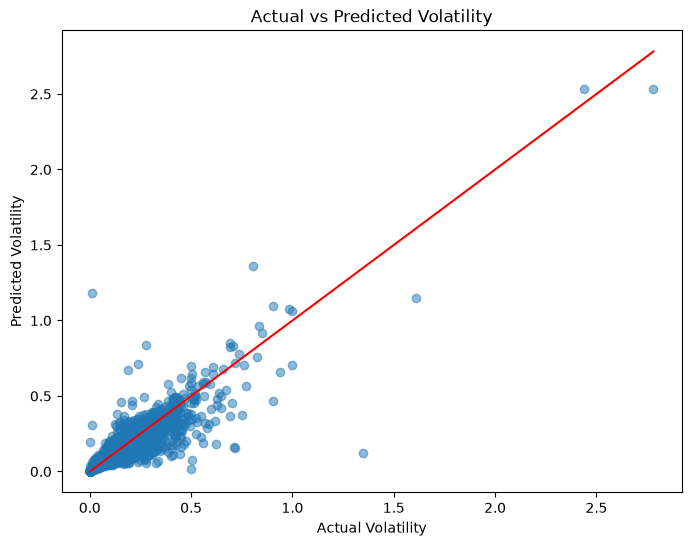

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Volatility")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [34]:
importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance

,Feature,Importance
6,daily_return,0.545747
11,rolling_volatility,0.243742
4,volume,0.054534
7,price_range,0.050629
5,marketCap,0.028659
8,liquidity_ratio,0.020302
1,high,0.013206
2,low,0.011171
10,MA30,0.009219
0,open,0.007423


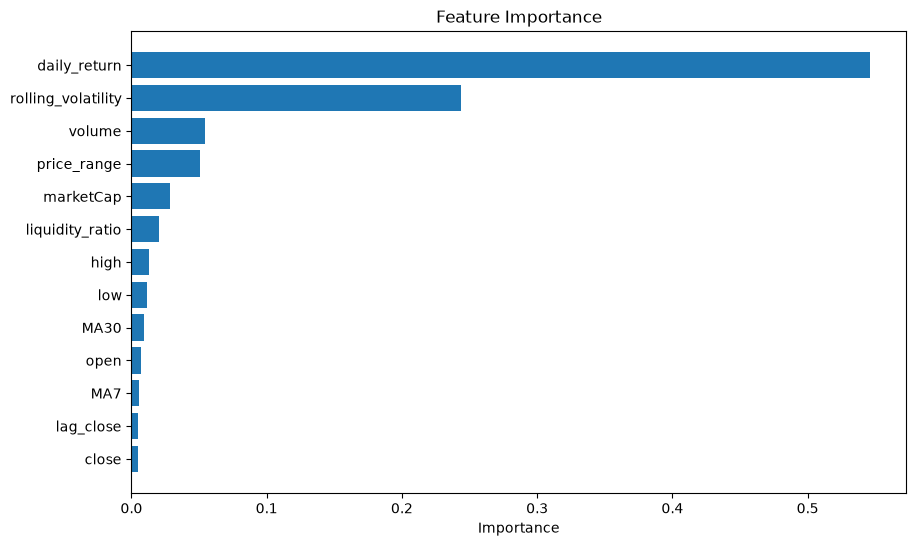

In [35]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [36]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")

print("Model Saved Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/random_forest_model.pkl'

In [37]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")

print("Model Saved Successfully!")


FileNotFoundError: [Errno 2] No such file or directory: '../models/random_forest_model.pkl'

In [38]:
import joblib

joblib.dump(model, "models/random_forest_model.pkl")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.0162251498470911
Root Mean Squared Error (RMSE): 0.03599609763469899
R² Score: 0.8210683157019042


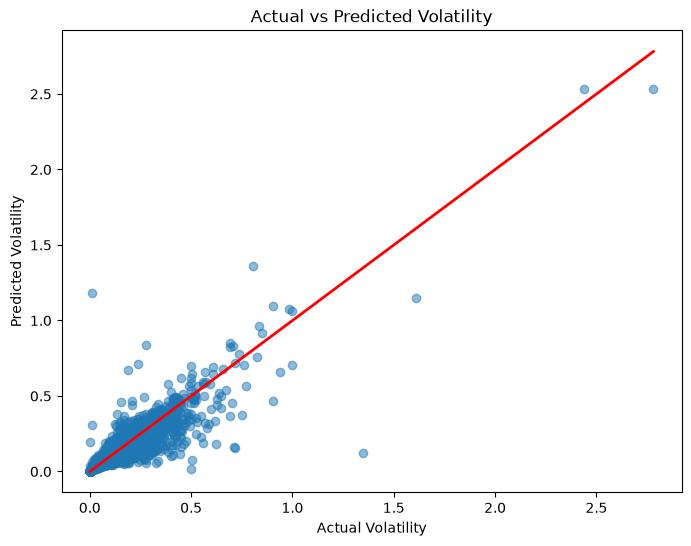

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Volatility")

plt.show()

In [42]:
importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance

,Feature,Importance
6,daily_return,0.545747
11,rolling_volatility,0.243742
4,volume,0.054534
7,price_range,0.050629
5,marketCap,0.028659
8,liquidity_ratio,0.020302
1,high,0.013206
2,low,0.011171
10,MA30,0.009219
0,open,0.007423


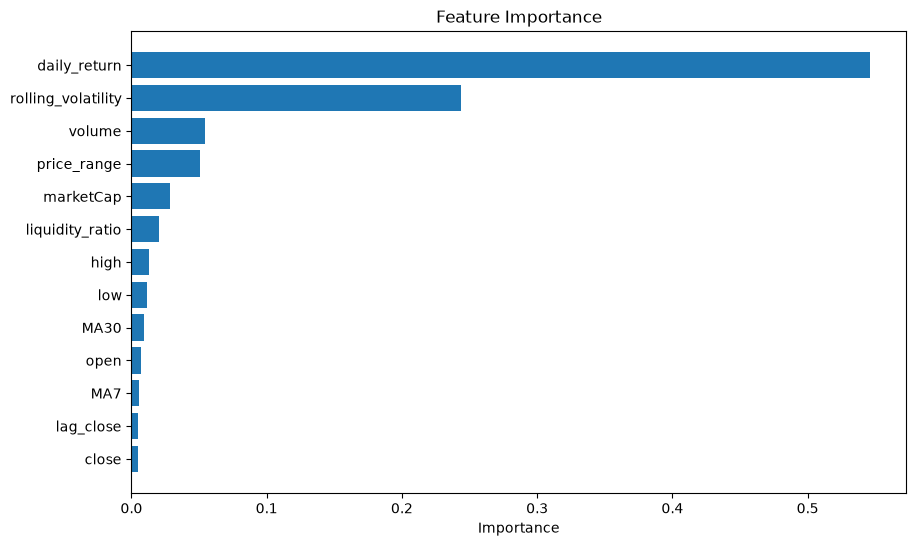

In [43]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()